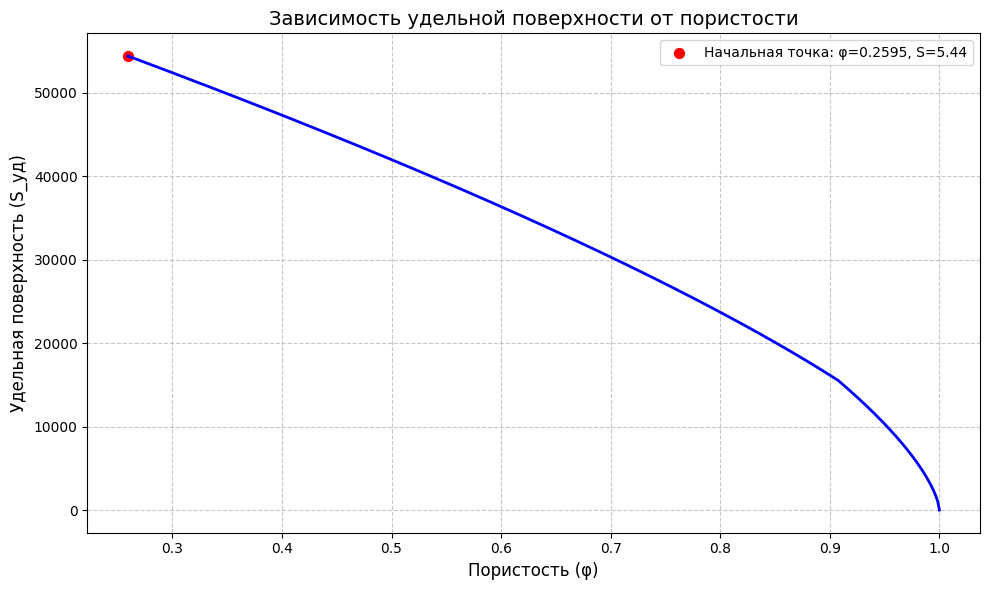

In [5]:
import math
import numpy as np
import matplotlib.pyplot as plt

# Исходные константы
phi_sh0 = math.pi / (3 * math.sqrt(2))  # ≈0.7405
phi_por0 = 1 - phi_sh0                  # ≈0.2595

# Теоретическое значение удельной поверхности при начальной пористости
S_ud_initial_theory = 5.44
# Расчетное значение по модели при начальной пористости
S_ud_initial_model = (3 * phi_sh0 * math.pi * 3.5) / 4  # ≈6.115
# Поправочный коэффициент
scale = S_ud_initial_theory / S_ud_initial_model

def area_sphere_surface(porosity, R0=1.0):
    """
    Вычисляет удельную поверхность пористого материала.
    
    Параметры:
        porosity (float): Пористость материала (от 0.2595 до 1).
        R0 (float): Начальный радиус шаров (по умолчанию 1.0).
        
    Возвращает:
        float: Удельная поверхность (единицы: 1/ед. длины).
    """
    if porosity >= 1.0:
        return 0.0
    if porosity <= phi_por0:
        x = 1.0
    else:
        phi_sh = 1 - porosity
        x = (phi_sh / phi_sh0) ** (1/3)
    
    K0 = (3 * phi_sh0 * math.pi) / 4
    
    if x > 0.5:
        S_ud_R0 = K0 * (4 * x**2 - x + 0.5)
    else:
        S_ud_R0 = 4 * K0 * x**2
    
    S_ud_R0_corrected = scale * S_ud_R0
    return S_ud_R0_corrected / R0

# Создание данных для графика
porosities = np.linspace(phi_por0, 1, 500)
areas = [area_sphere_surface(p, R0=0.0001) for p in porosities]

# Построение графика
plt.figure(figsize=(10, 6))
plt.plot(porosities, areas, color='b', linewidth=2)
plt.scatter(phi_por0, area_sphere_surface(phi_por0, R0=0.0001), color='r', s=50, label=f'Начальная точка: φ={phi_por0:.4f}, S={area_sphere_surface(phi_por0):.2f}')
plt.title('Зависимость удельной поверхности от пористости', fontsize=14)
plt.xlabel('Пористость (φ)', fontsize=12)
plt.ylabel('Удельная поверхность (S_уд)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()
